# Expected Goals on Target Model

## Imports

In [61]:
import sys
print(sys.executable)
import json
import time
import numpy as np
import pandas as pd
import joblib
from bs4 import BeautifulSoup

from pydantic import BaseModel
from typing import List, Optional

from selenium import webdriver
from tqdm import tqdm
from supabase import create_client, Client
import psycopg2
import re
import pandas as pd
import ast
from sklearn.model_selection import train_test_split

from tqdm import tqdm
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score
import pandas as pd


c:\Users\rogel\AppData\Local\Programs\Python\Python39\python.exe


## Fetching the Data

### Connecting to DB

In [62]:

conn = psycopg2.connect(
    dbname="postgres",
    user="postgres",
    password="admin",
    host="localhost",
    port=5432
)

In [63]:
cursor = conn.cursor()

In [64]:
cursor.execute("""
    SELECT * FROM match_events WHERE is_shot=TRUE;
""")

In [65]:
records = cursor.fetchall()

In [66]:
columns = [desc[0] for desc in cursor.description]

In [67]:
df = pd.DataFrame(records, columns=columns)

In [68]:
df.head()

,id,event_id,minute,second,team_id,player_id,x,y,end_x,end_y,...,blocked_y,goal_mouth_z,goal_mouth_y,is_shot,card_type,is_goal,type_display_name,outcome_type_display_name,period_display_name,match_id
0,2782443545,309,28,3.0,36,395472,95.2,65.8,None,None,...,61.7,19.0,49.6,True,False,False,SavedShot,Successful,FirstHalf,1834368.0
1,2782444679,314,28,50.0,36,344156,95.8,50.7,None,None,...,46.0,25.0,42.5,True,False,False,MissedShots,Successful,FirstHalf,1834368.0
2,2782444533,313,28,51.0,36,299077,95.1,49.0,None,None,...,62.1,34.7,40.3,True,False,False,MissedShots,Successful,FirstHalf,1834368.0
3,2782443953,312,28,53.0,36,299077,96.2,50.3,None,None,...,NaN,8.9,51.9,True,False,True,Goal,Successful,FirstHalf,1834368.0
4,2782446535,357,32,49.0,36,243565,90.8,55.7,None,None,...,NaN,2.5,54.1,True,False,True,Goal,Successful,FirstHalf,1834368.0


In [69]:
df.shape

(240237, 23)

In [70]:
df.columns

Index(['id', 'event_id', 'minute', 'second', 'team_id', 'player_id', 'x', 'y',
       'end_x', 'end_y', 'qualifiers', 'is_touch', 'blocked_x', 'blocked_y',
       'goal_mouth_z', 'goal_mouth_y', 'is_shot', 'card_type', 'is_goal',
       'type_display_name', 'outcome_type_display_name', 'period_display_name',
       'match_id'],
      dtype='object')

In [71]:
df['type_display_name'].unique()

array(['SavedShot', 'MissedShots', 'Goal', 'ShotOnPost'], dtype=object)

In [72]:
goal_shots = df[df['is_goal'] == 1]  # assuming 'goal' column: 1 if goal, else 0

print("Goal shots z coordinate:")
print(f"  min: {goal_shots['goal_mouth_z'].min()}")
print(f"  max: {goal_shots['goal_mouth_z'].max()}")

print("Goal shots y coordinate:")
print(f"  min: {goal_shots['goal_mouth_y'].min()}")
print(f"  max: {goal_shots['goal_mouth_y'].max()}")


Goal shots z coordinate:
  min: 0.6
  max: 37.3
Goal shots y coordinate:
  min: 45.2
  max: 54.8


In [73]:
goal_shots = df[df['type_display_name'] == 'ShotOnPost']  # assuming 'goal' column: 1 if goal, else 0

print("Goal shots z coordinate:")
print(f"  min: {goal_shots['goal_mouth_z'].min()}")
print(f"  max: {goal_shots['goal_mouth_z'].max()}")

print("Goal shots y coordinate:")
print(f"  min: {goal_shots['goal_mouth_y'].min()}")
print(f"  max: {goal_shots['goal_mouth_y'].max()}")


Goal shots z coordinate:
  min: 0.6
  max: 41.8
Goal shots y coordinate:
  min: 44.2
  max: 55.8


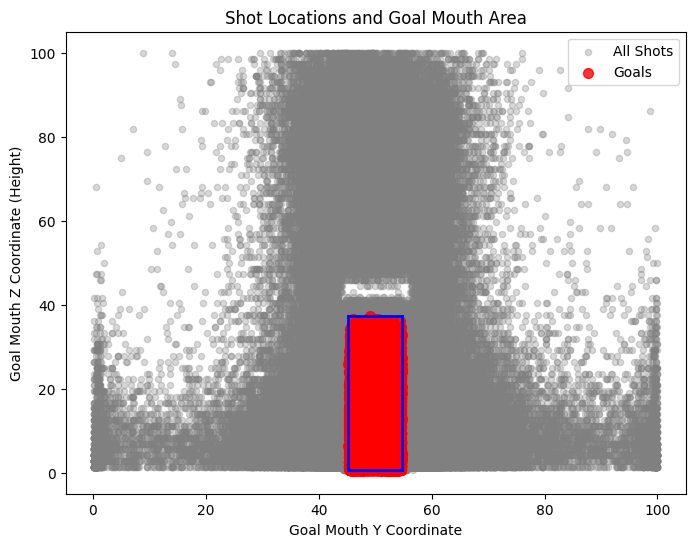

In [74]:
import matplotlib.pyplot as plt

# Filter shots that have goal mouth coordinates (not null)
goal_shots = df[df['is_goal'] == 1].dropna(subset=['goal_mouth_y', 'goal_mouth_z'])
all_shots = df.dropna(subset=['goal_mouth_y', 'goal_mouth_z'])

plt.figure(figsize=(8, 6))
# Plot all shots
plt.scatter(all_shots['goal_mouth_y'], all_shots['goal_mouth_z'], 
            alpha=0.3, label='All Shots', color='gray', s=20)

# Highlight goals
plt.scatter(goal_shots['goal_mouth_y'], goal_shots['goal_mouth_z'], 
            alpha=0.8, label='Goals', color='red', s=50)

# Plot goal mouth rectangle boundaries based on min/max from your data
min_y, max_y = goal_shots['goal_mouth_y'].min(), goal_shots['goal_mouth_y'].max()
min_z, max_z = goal_shots['goal_mouth_z'].min(), goal_shots['goal_mouth_z'].max()

# Draw goal mouth box
plt.plot([min_y, min_y], [min_z, max_z], color='blue', lw=2)
plt.plot([max_y, max_y], [min_z, max_z], color='blue', lw=2)
plt.plot([min_y, max_y], [min_z, min_z], color='blue', lw=2)
plt.plot([min_y, max_y], [max_z, max_z], color='blue', lw=2)

plt.xlabel('Goal Mouth Y Coordinate')
plt.ylabel('Goal Mouth Z Coordinate (Height)')
plt.title('Shot Locations and Goal Mouth Area')
plt.legend()
#plt.gca().invert_yaxis()  # Invert Z if height is from ground upwards
plt.show()


## Data Processing

### Filter on target only

In [75]:
df = df[df['type_display_name'].isin(['Goal', 'SavedShot'])]

### Qualifier Analysis

In [76]:
import pandas as pd
import ast

# Step 1: Safely convert string to list of dicts
def extract_display_names(qualifiers_string):
    if pd.isna(qualifiers_string):
        return []
    try:
        qualifiers = ast.literal_eval(qualifiers_string)
        return [q['type']['displayName'] for q in qualifiers if 'type' in q and 'displayName' in q['type']]
    except Exception:
        return []

# Step 2: Apply to your DataFrame
df['display_names'] = df['qualifiers'].apply(extract_display_names)

# Step 3: Flatten and get unique display names
all_display_names = set(name for sublist in df['display_names'] for name in sublist)

print(f"Unique display names: {sorted(all_display_names)}")


Unique display names: ['Assisted', 'BigChance', 'BigChanceCreated', 'Blocked', 'BlockedX', 'BlockedY', 'BoxCentre', 'BoxLeft', 'BoxRight', 'DeepBoxLeft', 'DeepBoxRight', 'DirectCorner', 'DirectFreekick', 'FastBreak', 'FirstTouch', 'FromCorner', 'GoalMouthY', 'GoalMouthZ', 'Head', 'HighCentre', 'HighLeft', 'HighRight', 'IndividualPlay', 'IntentionalAssist', 'IntentionalGoalAssist', 'KeyPass', 'LeftFoot', 'LowCentre', 'LowLeft', 'LowRight', 'OneOnOne', 'OppositeRelatedEvent', 'OtherBodyPart', 'OutOfBoxCentre', 'OutOfBoxDeepLeft', 'OutOfBoxDeepRight', 'OutOfBoxLeft', 'OutOfBoxRight', 'OwnGoal', 'Penalty', 'RegularPlay', 'RelatedEventId', 'RightFoot', 'SavedOffline', 'SetPiece', 'SixYardBlock', 'SmallBoxCentre', 'SmallBoxLeft', 'SmallBoxRight', 'StandingSave', 'ThirtyFivePlusCentre', 'ThirtyFivePlusLeft', 'ThirtyFivePlusRight', 'ThrowinSetPiece', 'Volley', 'Zone']


### Add Qualifiers to model

In [77]:

# List of qualifiers you're interested in
qualifiers_of_interest = [
    'IntentionalAssist', 'IntentionalGoalAssist', 'Assisted', 'KeyPass', 'IndividualPlay',
    'RightFoot', 'LeftFoot', 'Head', 'OtherBodyPart', 'Volley', 'SetPiece', 'DirectFreekick', 'OneOnOne'
    ,'Penalty', 'DirectCorner'
]

# Function to extract display names
def extract_display_names(qualifiers_string):
    if pd.isna(qualifiers_string):
        return []
    try:
        qualifiers = ast.literal_eval(qualifiers_string)
        return [q['type']['displayName'] for q in qualifiers if 'type' in q and 'displayName' in q['type']]
    except Exception:
        return []

# Get list of display names per row
df['display_names'] = df['qualifiers'].apply(extract_display_names)

# Create binary columns for each qualifier
for qualifier in qualifiers_of_interest:
    df[f'qual_{qualifier}'] = df['display_names'].apply(lambda x: 1 if qualifier in x else 0)

# Optional: drop the intermediate column if you don’t need it
# df.drop(columns=['display_names'], inplace=True)



In [78]:
df.columns

Index(['id', 'event_id', 'minute', 'second', 'team_id', 'player_id', 'x', 'y',
       'end_x', 'end_y', 'qualifiers', 'is_touch', 'blocked_x', 'blocked_y',
       'goal_mouth_z', 'goal_mouth_y', 'is_shot', 'card_type', 'is_goal',
       'type_display_name', 'outcome_type_display_name', 'period_display_name',
       'match_id', 'display_names', 'qual_IntentionalAssist',
       'qual_IntentionalGoalAssist', 'qual_Assisted', 'qual_KeyPass',
       'qual_IndividualPlay', 'qual_RightFoot', 'qual_LeftFoot', 'qual_Head',
       'qual_OtherBodyPart', 'qual_Volley', 'qual_SetPiece',
       'qual_DirectFreekick', 'qual_OneOnOne', 'qual_Penalty',
       'qual_DirectCorner'],
      dtype='object')

### Quantitative variables

In [79]:
df['centered_y'] = 50 - abs(df['y'] - 50)
df['centered_goalmouth_y'] = 50 - abs(df['goal_mouth_y'] - 50)

In [80]:
import numpy as np

def calculate_shot_angle(x, y):
    goal_x, goal_y_top, goal_y_bottom = 100, 56, 44
    dx = goal_x - x
    dy_top = goal_y_top - y
    dy_bottom = goal_y_bottom - y
    
    # Angles from (x,y) to top and bottom posts
    angle_top = np.arctan2(dy_top, dx)
    angle_bottom = np.arctan2(dy_bottom, dx)
    
    # Angle between lines (always positive)
    angle = abs(angle_top - angle_bottom)
    
    # Convert to degrees
    return np.degrees(angle)

df['shot_angle'] = df.apply(lambda row: calculate_shot_angle(row['x'], row['y']), axis=1)

In [81]:
# Distance to center (you already have this):
df['distance_to_goal_center'] = np.sqrt((100 - df['x'])**2 + (50 - df['y'])**2)

# Distance to left post
df['distance_to_left_post'] = np.sqrt((100 - df['x'])**2 + (44 - df['y'])**2)

# Distance to right post
df['distance_to_right_post'] = np.sqrt((100 - df['x'])**2 + (56 - df['y'])**2)

### Extra Vars

In [82]:
# 1. Distance × Angle — close shots at bad angles vs far shots at good angles
df['dist_angle'] = df['distance_to_goal_center'] * df['shot_angle']

# 2. One-on-one within 10m — high conversion zone for 1v1
df['one_on_one_near'] = df['qual_OneOnOne'] * (df['distance_to_goal_center'] < 10).astype(int)

# 3. Strong foot at tight angle — can the player score from a sharp position?
df['tight_angle_strong_foot'] = df['shot_angle'] * (
    (df['qual_RightFoot'] | df['qual_LeftFoot']).astype(int)
)

# 4. Header far from goal — headers lose power with distance
df['header_far'] = df['qual_Head'] * (df['distance_to_goal_center'] > 12).astype(int)

# 5. Volley in central position — more dangerous than wide volleys
df['central_volley'] = df['qual_Volley'] * (df['centered_y'] < 2).astype(int)

# 6. Header from corner — headers following a corner kick
df['header_from_corner'] = df['qual_Head'] * df['qual_DirectCorner']

# 7. Sharp angle with opposite foot — usually worse finishing
df['sharp_angle_weak_foot'] = (df['shot_angle'] > 30).astype(int) * (
    (~df['qual_RightFoot'] & ~df['qual_LeftFoot']).astype(int)
)

# 8. Cross + header — classic aerial danger pattern
df['cross_header'] = (df['qual_Assisted'] | df['qual_IntentionalAssist']).astype(int) * df['qual_Head']

# 9. Set piece danger zone — set piece + close distance
df['setpiece_close'] = df['qual_SetPiece'] * (df['distance_to_goal_center'] < 12).astype(int)

# 10. Angle efficiency — ratio of angle to distance
df['angle_efficiency'] = df['shot_angle'] / (df['distance_to_goal_center'] + 1e-6)


### Feature Selection

In [83]:
xg_features = [
    'x', 'y',
    'qual_IntentionalAssist', 'qual_IntentionalGoalAssist', 'qual_Assisted',
    'qual_KeyPass', 'qual_IndividualPlay', 'qual_RightFoot', 'qual_LeftFoot',
    'qual_Head', 'qual_OtherBodyPart', 'qual_Volley', 'qual_SetPiece',
       'qual_DirectFreekick', 'qual_OneOnOne', 'qual_Penalty',
       'qual_DirectCorner', 'shot_angle', 'centered_y', 'distance_to_goal_center', 'distance_to_left_post', 'distance_to_right_post', 'goal_mouth_y', 'goal_mouth_z', 'centered_goalmouth_y',
       'dist_angle',
    'one_on_one_near',
    'tight_angle_strong_foot',
    'header_far',
    'central_volley',
    'header_from_corner',
    'sharp_angle_weak_foot',
    'cross_header',
    'setpiece_close',
    'angle_efficiency'
]
target = 'is_goal'


In [84]:
final_columns = xg_features + [target]
df = df[final_columns].copy()

### Type selection

In [85]:
print(df.dtypes.to_frame(name='Data Type'))

                           Data Type
x                            float64
y                            float64
qual_IntentionalAssist         int64
qual_IntentionalGoalAssist     int64
qual_Assisted                  int64
qual_KeyPass                   int64
qual_IndividualPlay            int64
qual_RightFoot                 int64
qual_LeftFoot                  int64
qual_Head                      int64
qual_OtherBodyPart             int64
qual_Volley                    int64
qual_SetPiece                  int64
qual_DirectFreekick            int64
qual_OneOnOne                  int64
qual_Penalty                   int64
qual_DirectCorner              int64
shot_angle                   float64
centered_y                   float64
distance_to_goal_center      float64
distance_to_left_post        float64
distance_to_right_post       float64
goal_mouth_y                 float64
goal_mouth_z                 float64
centered_goalmouth_y         float64
dist_angle                   float64
o

In [86]:
nan_counts = df.isna().sum()
nan_counts = nan_counts[nan_counts > 0]  # Filter columns with any NaNs

print("Columns with NaNs and their counts:")
print(nan_counts)

print("\nNumber of rows with any NaN value:")
print(df.isna().any(axis=1).sum())


Columns with NaNs and their counts:
goal_mouth_y            1
goal_mouth_z            1
centered_goalmouth_y    1
dtype: int64

Number of rows with any NaN value:
1


In [87]:
df_clean = df.dropna(inplace=True)

In [88]:
nan_counts = df.isna().sum()
nan_counts = nan_counts[nan_counts > 0]  # Filter columns with any NaNs

print("Columns with NaNs and their counts:")
print(nan_counts)

print("\nNumber of rows with any NaN value:")
print(df.isna().any(axis=1).sum())


Columns with NaNs and their counts:
Series([], dtype: int64)

Number of rows with any NaN value:
0


### Final Edits

backup_df=df

In [89]:
df = df[~((df['x'] < 50) & (df['is_goal'] == 1))]

In [90]:
df.columns

Index(['x', 'y', 'qual_IntentionalAssist', 'qual_IntentionalGoalAssist',
       'qual_Assisted', 'qual_KeyPass', 'qual_IndividualPlay',
       'qual_RightFoot', 'qual_LeftFoot', 'qual_Head', 'qual_OtherBodyPart',
       'qual_Volley', 'qual_SetPiece', 'qual_DirectFreekick', 'qual_OneOnOne',
       'qual_Penalty', 'qual_DirectCorner', 'shot_angle', 'centered_y',
       'distance_to_goal_center', 'distance_to_left_post',
       'distance_to_right_post', 'goal_mouth_y', 'goal_mouth_z',
       'centered_goalmouth_y', 'dist_angle', 'one_on_one_near',
       'tight_angle_strong_foot', 'header_far', 'central_volley',
       'header_from_corner', 'sharp_angle_weak_foot', 'cross_header',
       'setpiece_close', 'angle_efficiency', 'is_goal'],
      dtype='object')

Remove Penalties

In [91]:
#df = df[df['qual_Penalty'] != 1]

### final df

In [92]:
final_columns = xg_features + [target]
df_xg = df[final_columns].copy()

## Modelling

### Train test

In [93]:

# Features and target
X = df_xg.drop(columns=[target])
y = df_xg[target]

# 50-50 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

### Model Comparisson

In [94]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import numpy as np


classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(random_seed=42, verbose=0, loss_function='Logloss'),
    "CatBoost_balanced": CatBoostClassifier(random_seed=42, verbose=0, loss_function='Logloss',auto_class_weights='Balanced')
}

results = []


for name, clf in tqdm(classifiers.items(), desc="Training classifiers"):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    # Brier Score
    brier = brier_score_loss(y_test, y_proba)

    # Calibration Error (mean absolute difference between predicted prob and actual fraction)
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')
    calibration_error = np.mean(np.abs(prob_true - prob_pred))

    results.append({
        "Classifier": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "F1 Score": round(f1_score(y_test, y_pred), 3),
        "ROC AUC": round(roc_auc_score(y_test, y_proba), 3),
        "Brier Score": round(brier, 3),
        "Calibration Error": round(calibration_error, 3)
    })

results_df = pd.DataFrame(results)
print(results_df)



Training classifiers: 100%|██████████| 6/6 [02:10<00:00, 21.77s/it]

            Classifier  Accuracy  Precision  Recall  F1 Score  ROC AUC  \
0  Logistic Regression     0.861      0.707   0.395     0.507    0.860   
1        Random Forest     0.878      0.724   0.524     0.608    0.912   
2    Gradient Boosting     0.881      0.717   0.564     0.631    0.921   
3              XGBoost     0.889      0.727   0.619     0.669    0.930   
4             CatBoost     0.894      0.747   0.625     0.680    0.935   
5    CatBoost_balanced     0.850      0.554   0.869     0.677    0.934   

   Brier Score  Calibration Error  
0        0.101              0.023  
1        0.086              0.023  
2        0.083              0.019  
3        0.078              0.010  
4        0.075              0.010  
5        0.103              0.213  


### Catboost Hyperopt (best model)

In [95]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from catboost import CatBoostClassifier
from sklearn.metrics import brier_score_loss
import numpy as np

# Objective function to minimize (Brier score)
def objective(params):
    model = CatBoostClassifier(
        iterations=int(params['iterations']),  # cast to int
        learning_rate=params['learning_rate'],
        depth=int(params['depth']),
        l2_leaf_reg=params['l2_leaf_reg'],
        random_seed=42,
        loss_function='Logloss',
        verbose=0,
        task_type='GPU',
    )
    model.fit(X_train, y_train)
    
    # Use predicted probabilities for Brier score
    y_prob = model.predict_proba(X_test)[:, 1]
    brier = brier_score_loss(y_test, y_prob)
    
    return {'loss': brier, 'status': STATUS_OK}

# Hyperparameter search space
space = {
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'depth': hp.quniform('depth', 4, 15, 1),
    'l2_leaf_reg': hp.uniform('l2_leaf_reg', 1, 10),
    'iterations': hp.quniform('iterations', 100, 2000, 50)  # new iterations param
}

# Running hyperopt
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(42)
)

print("Best hyperparameters:", best)


100%|██████████| 50/50 [21:00<00:00, 25.22s/trial, best loss: 0.07559405969400396]
Best hyperparameters: {'depth': 5.0, 'iterations': 1950.0, 'l2_leaf_reg': 1.061838213379967, 'learning_rate': 0.053850786985987574}


In [96]:
best_model = CatBoostClassifier(
    iterations=int(best['iterations']),
    learning_rate=best['learning_rate'],
    depth=int(best['depth']),
    l2_leaf_reg=best['l2_leaf_reg'],
    random_seed=42,
    verbose=100,
    task_type='GPU',
    loss_function='Logloss',

)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


0:	learn: 0.6158727	total: 6.71ms	remaining: 13.1s
100:	learn: 0.2629168	total: 535ms	remaining: 9.79s
200:	learn: 0.2522134	total: 1.12s	remaining: 9.73s
300:	learn: 0.2465887	total: 1.62s	remaining: 8.89s
400:	learn: 0.2421817	total: 2.13s	remaining: 8.23s
500:	learn: 0.2387063	total: 2.67s	remaining: 7.74s
600:	learn: 0.2360993	total: 3.23s	remaining: 7.26s
700:	learn: 0.2339219	total: 3.76s	remaining: 6.7s
800:	learn: 0.2318989	total: 4.3s	remaining: 6.17s
900:	learn: 0.2301553	total: 4.87s	remaining: 5.67s
1000:	learn: 0.2283154	total: 5.47s	remaining: 5.19s
1100:	learn: 0.2266063	total: 5.99s	remaining: 4.62s
1200:	learn: 0.2250987	total: 6.5s	remaining: 4.06s
1300:	learn: 0.2235748	total: 7.03s	remaining: 3.51s
1400:	learn: 0.2221762	total: 7.54s	remaining: 2.96s
1500:	learn: 0.2208124	total: 8.05s	remaining: 2.41s
1600:	learn: 0.2194332	total: 8.56s	remaining: 1.86s
1700:	learn: 0.2180746	total: 9.06s	remaining: 1.33s
1800:	learn: 0.2168005	total: 9.57s	remaining: 792ms
1900:	l

## Results Analysis

In [97]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 3))

# Print confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Accuracy: 0.893
Precision: 0.746
Recall: 0.621
F1 Score: 0.678
ROC AUC: 0.935
Confusion Matrix:
[[28548  1394]
 [ 2499  4097]]


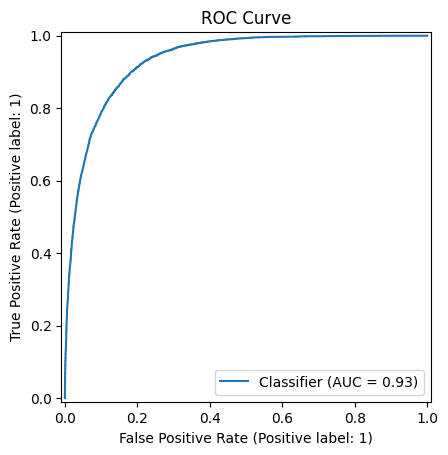

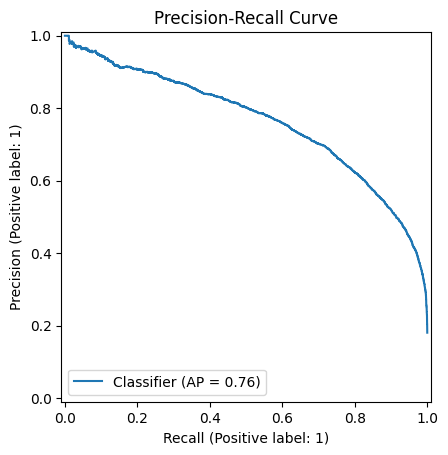

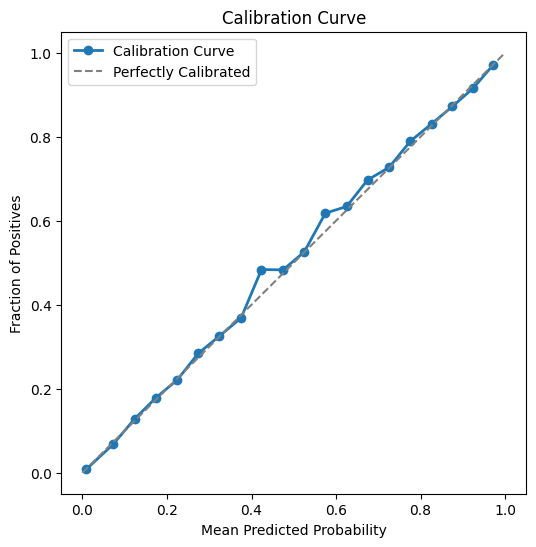

In [98]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.calibration import calibration_curve

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve")
plt.show()

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision-Recall Curve")
plt.show()

# Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=20, strategy='uniform')

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Calibration Curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.show()


C:\Users\rogel\AppData\Local\Temp\ipykernel_2680\3567450978.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')


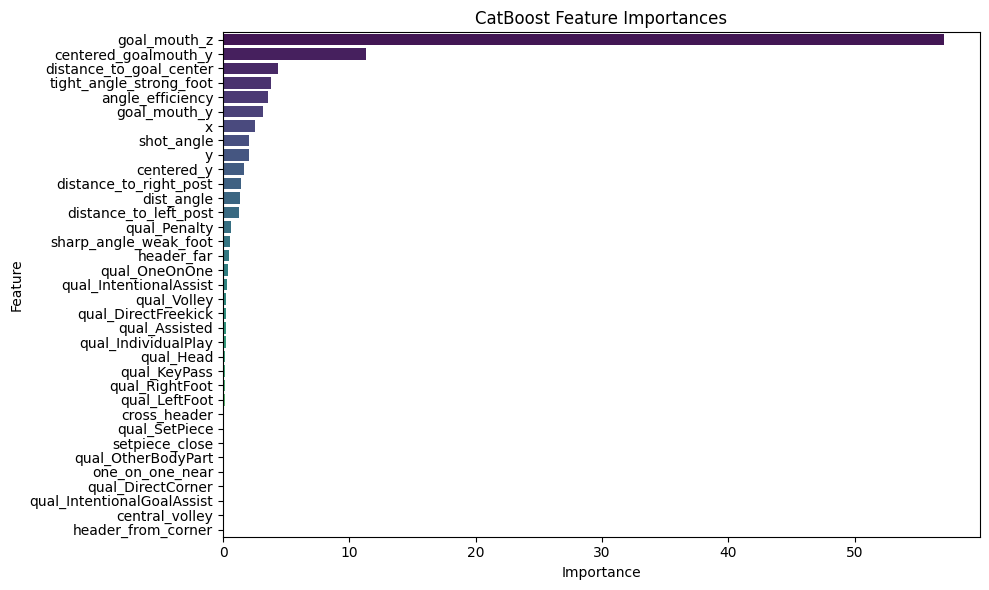

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances
importances = best_model.get_feature_importance()
feature_names = X_train.columns

# Create DataFrame for plotting
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title("CatBoost Feature Importances")
plt.tight_layout()
plt.show()


In [100]:
# Replace `model` with the name of your trained model
joblib.dump(best_model, 'xgot_model.pkl')

['xgot_model.pkl']

In [101]:
model = joblib.load('xgot_model.pkl')

## Test -- Undersampling

In [102]:
y_train

79871     False
215713    False
37166     False
186861     True
203129    False
          ...  
124448    False
59984     False
44047      True
55161      True
238620    False
Name: is_goal, Length: 109614, dtype: bool

In [103]:
# Print current class ratio
minority_count = (y_train == 1).sum()
majority_count = (y_train == 0).sum()
current_ratio = majority_count / minority_count if minority_count > 0 else None
print(f"Current majority:minority ratio is {current_ratio:.2f} (majority: {majority_count}, minority: {minority_count})")

Current majority:minority ratio is 4.54 (majority: 89827, minority: 19787)


In [104]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler

# Combine X and y for processing
train_df = pd.concat([X_train, y_train], axis=1)

# Identify majority and minority class
minority_class = train_df[target].value_counts().idxmin()
minority_count = train_df[target].value_counts()[minority_class]

# Store balanced datasets
balanced_datasets = {}

# Loop through ratios 1 to 8
for ratio in range(1, 9):
    desired_majority_count = min(len(train_df[train_df[target] != minority_class]), minority_count * ratio)

    # Define sampling strategy
    sampling_strategy = {
        minority_class: minority_count,
        1 - minority_class: desired_majority_count
    }

    # Apply RandomUnderSampler
    rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
    X_res, y_res = rus.fit_resample(X_train, y_train)

    # Save to dictionary
    balanced_datasets[ratio] = (X_res, y_res)

    # Print class distribution
    print(f"Ratio {ratio}: Class distribution = {y_res.value_counts().to_dict()}")

# Example usage:
# X_train_bal_3, y_train_bal_3 = balanced_datasets[3]


Ratio 1: Class distribution = {False: 19787, True: 19787}
Ratio 2: Class distribution = {False: 39574, True: 19787}
Ratio 3: Class distribution = {False: 59361, True: 19787}
Ratio 4: Class distribution = {False: 79148, True: 19787}
Ratio 5: Class distribution = {False: 89827, True: 19787}
Ratio 6: Class distribution = {False: 89827, True: 19787}
Ratio 7: Class distribution = {False: 89827, True: 19787}
Ratio 8: Class distribution = {False: 89827, True: 19787}


### Modeling for undersampled dataset

In [105]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    brier_score_loss, log_loss, matthews_corrcoef  # ✅ Added
)

from tqdm import tqdm
import pandas as pd


# Store models, reports, and results
catboost_models = {}
catboost_reports = {}
results = []

# Loop over each class ratio with a progress bar
for ratio in tqdm(range(1, 9), desc="Training CatBoost models (GPU)", unit="model"):
    X_bal, y_bal = balanced_datasets[ratio]

    # Initialize CatBoost model
    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        task_type="GPU",
        devices='0',
        verbose=0,
        random_seed=42,
        loss_function='Logloss'
    )

    # Fit model
    model.fit(X_bal, y_bal)

    # Predict class and probabilities
    y_pred_bal = model.predict(X_test)
    y_proba_bal = model.predict_proba(X_test)[:, 1]

    # Compute metrics
    acc = accuracy_score(y_test, y_pred_bal)
    prec = precision_score(y_test, y_pred_bal)
    rec = recall_score(y_test, y_pred_bal)
    f1 = f1_score(y_test, y_pred_bal)
    roc = roc_auc_score(y_test, y_proba_bal)
    # Compute additional metrics
    brier = brier_score_loss(y_test, y_proba_bal)
    logloss = log_loss(y_test, y_proba_bal)
    mcc = matthews_corrcoef(y_test, y_pred_bal)

    # Append all metrics
    results.append({
        "Classifier": f"CatBoost (Ratio {ratio})",
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1 Score": round(f1, 3),
        "ROC AUC": round(roc, 3),
        "Brier Score": round(brier, 3),
        "Log Loss": round(logloss, 3),
        "MCC": round(mcc, 3)
    })

    # Save model and full report
    catboost_models[ratio] = model
    catboost_reports[ratio] = classification_report(y_test, y_pred_bal, output_dict=True)

import pandas as pd

results_df = pd.DataFrame(results)
display(results_df)  # If you're in Jupyter
print(results_df)    # If in a script


Training CatBoost models (GPU): 100%|██████████| 8/8 [01:10<00:00,  8.81s/model]


,Classifier,Accuracy,Precision,Recall,F1 Score,ROC AUC,Brier Score,Log Loss,MCC
0,CatBoost (Ratio 1),0.835,0.525,0.886,0.659,0.931,0.112,0.343,0.592
1,CatBoost (Ratio 2),0.878,0.630,0.786,0.700,0.934,0.085,0.269,0.630
2,CatBoost (Ratio 3),0.890,0.689,0.709,0.699,0.934,0.078,0.249,0.632
3,CatBoost (Ratio 4),0.894,0.734,0.648,0.688,0.934,0.076,0.242,0.626
4,CatBoost (Ratio 5),0.892,0.745,0.615,0.673,0.934,0.076,0.242,0.614
5,CatBoost (Ratio 6),0.893,0.746,0.616,0.675,0.934,0.076,0.243,0.616
6,CatBoost (Ratio 7),0.892,0.745,0.615,0.673,0.934,0.076,0.242,0.614
7,CatBoost (Ratio 8),0.892,0.745,0.615,0.673,0.934,0.076,0.242,0.614


           Classifier  Accuracy  Precision  Recall  F1 Score  ROC AUC  \
0  CatBoost (Ratio 1)     0.835      0.525   0.886     0.659    0.931   
1  CatBoost (Ratio 2)     0.878      0.630   0.786     0.700    0.934   
2  CatBoost (Ratio 3)     0.890      0.689   0.709     0.699    0.934   
3  CatBoost (Ratio 4)     0.894      0.734   0.648     0.688    0.934   
4  CatBoost (Ratio 5)     0.892      0.745   0.615     0.673    0.934   
5  CatBoost (Ratio 6)     0.893      0.746   0.616     0.675    0.934   
6  CatBoost (Ratio 7)     0.892      0.745   0.615     0.673    0.934   
7  CatBoost (Ratio 8)     0.892      0.745   0.615     0.673    0.934   

   Brier Score  Log Loss    MCC  
0        0.112     0.343  0.592  
1        0.085     0.269  0.630  
2        0.078     0.249  0.632  
3        0.076     0.242  0.626  
4        0.076     0.242  0.614  
5        0.076     0.243  0.616  
6        0.076     0.242  0.614  
7        0.076     0.242  0.614  


In [106]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, brier_score_loss,
    log_loss, matthews_corrcoef
)
import pandas as pd

tuned_results = []

for ratio in range(1, 9):
    model = catboost_models[ratio]
    y_proba = model.predict_proba(X_test)[:, 1]

    # Find best threshold maximizing F1
    thresholds = np.linspace(0, 1, 101)
    f1_scores = []
    for thr in thresholds:
        y_pred_thr = (y_proba >= thr).astype(int)
        f1_scores.append(f1_score(y_test, y_pred_thr))
    best_idx = np.argmax(f1_scores)
    best_thr = thresholds[best_idx]

    # Predict with best threshold
    y_pred_best = (y_proba >= best_thr).astype(int)

    # Calculate metrics at best threshold
    acc = accuracy_score(y_test, y_pred_best)
    prec = precision_score(y_test, y_pred_best)
    rec = recall_score(y_test, y_pred_best)
    f1 = f1_score(y_test, y_pred_best)
    roc = roc_auc_score(y_test, y_proba)  # ROC AUC uses probabilities
    brier = brier_score_loss(y_test, y_proba)
    logloss = log_loss(y_test, y_proba)
    mcc = matthews_corrcoef(y_test, y_pred_best)

    # Append results
    tuned_results.append({
        "Classifier": f"CatBoost (Ratio {ratio})",
        "Best Threshold": round(best_thr, 3),
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1 Score": round(f1, 3),
        "ROC AUC": round(roc, 3),
        "Brier Score": round(brier, 3),
        "Log Loss": round(logloss, 3),
        "MCC": round(mcc, 3)
    })

# Create and print summary DataFrame
tuned_results_df = pd.DataFrame(tuned_results)
print(tuned_results_df)


           Classifier  Best Threshold  Accuracy  Precision  Recall  F1 Score  \
0  CatBoost (Ratio 1)            0.71     0.884      0.658   0.743     0.698   
1  CatBoost (Ratio 2)            0.55     0.885      0.660   0.750     0.702   
2  CatBoost (Ratio 3)            0.46     0.887      0.669   0.742     0.704   
3  CatBoost (Ratio 4)            0.41     0.890      0.685   0.726     0.705   
4  CatBoost (Ratio 5)            0.35     0.887      0.667   0.748     0.705   
5  CatBoost (Ratio 6)            0.36     0.888      0.673   0.740     0.705   
6  CatBoost (Ratio 7)            0.35     0.887      0.667   0.748     0.705   
7  CatBoost (Ratio 8)            0.35     0.887      0.667   0.748     0.705   

   ROC AUC  Brier Score  Log Loss    MCC  
0    0.931        0.112     0.343  0.628  
1    0.934        0.085     0.269  0.633  
2    0.934        0.078     0.249  0.636  
3    0.934        0.076     0.242  0.638  
4    0.934        0.076     0.242  0.638  
5    0.934        0.0

Notes: The best model seems to be the original, undersampling has no positive effect on xG. 

## Plotting xG

### Getting the xg values

In [107]:
model = joblib.load('xgot_model.pkl')

In [108]:
# Predict xG values using the trained model
xg_values = model.predict_proba(df_xg.drop(columns=[target]))[:, 1]

# Assign the predicted values
df_xg['xG'] = xg_values

# Overwrite xG for penalty shots with 0.72
#df_xg.loc[df_xg['qual_Penalty'] == 1, 'xG'] = 0.72

# Preview
print(df_xg[['xG']].head())


         xG
0  0.006983
3  0.613178
4  0.783412
5  0.319384
6  0.153878


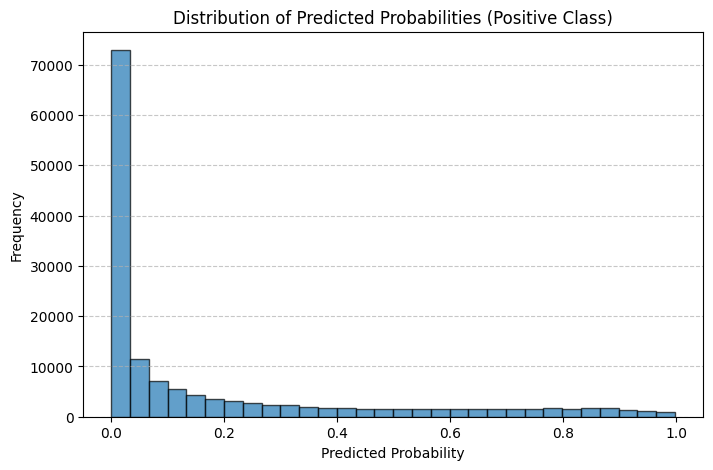

In [109]:
import matplotlib.pyplot as plt
import numpy as np

# Example: y_pred is your CatBoost predict_proba output for the positive class
# y_pred = model.predict_proba(X)[:, 1]

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(df_xg[['xG']], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Probabilities (Positive Class)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [110]:
high_xg = df_xg[df_xg['xG'] > 0.95]

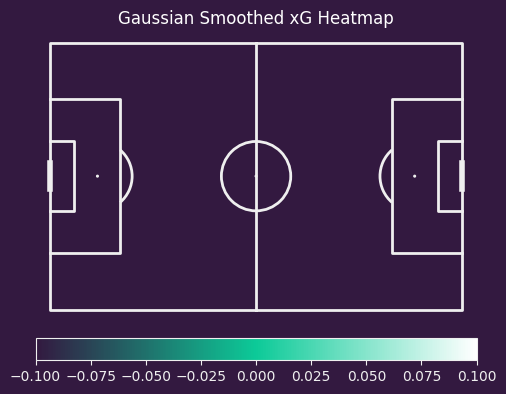

In [111]:
from mplsoccer import Pitch
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
df_filtered = high_xg[(high_xg['x'] > 50) & (high_xg['y'] > 0)]  # change thresholds as needed

# Custom colormap: dark purple → teal → white
colors = ['#331940', '#0cca98', 'white']
custom_cmap = LinearSegmentedColormap.from_list('xg_cmap', colors)

# Setup pitch
pitch = Pitch(pitch_type='opta', line_zorder=2,
              pitch_color='#331940', line_color='#efefef')  # dark purple pitch
fig, ax = pitch.draw(figsize=(6.6, 4.125))
fig.set_facecolor('#331940')  # figure background

# Compute mean xG per spatial bin
bin_statistic = pitch.bin_statistic(high_xg['x'], high_xg['y'], values=high_xg['xG'],
                                    statistic='mean', bins=(100, 50))

# Apply Gaussian smoothing to the binned xG values
sigma = 0.75
smoothed_xG = gaussian_filter(bin_statistic['statistic'], sigma=sigma)
bin_statistic['statistic'] = smoothed_xG

# Plot heatmap with custom colormap, no bin borders
pcm = pitch.heatmap(bin_statistic, ax=ax, cmap=custom_cmap, edgecolors=None)

# Add colorbar at the bottom
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cbar.outline.set_edgecolor('#efefef')
cbar.ax.xaxis.set_tick_params(color='#efefef')
plt.setp(plt.getp(cbar.ax.axes, 'xticklabels'), color='#efefef')

plt.title('Gaussian Smoothed xG Heatmap', color='white')
plt.tight_layout()
plt.show()


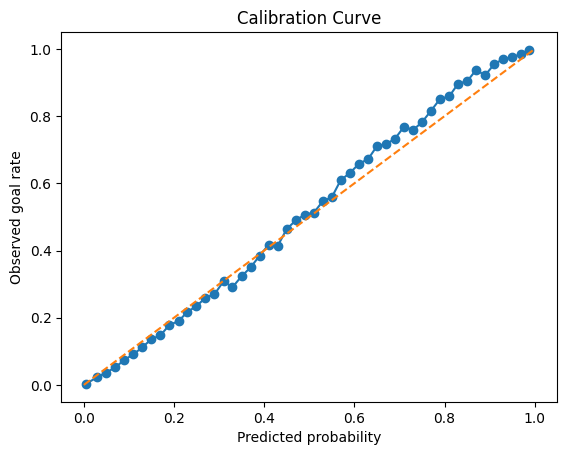

In [112]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    df_xg['is_goal'],     # True labels
    df_xg['xG'],          # Predicted probabilities
    n_bins=50
)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Predicted probability")
plt.ylabel("Observed goal rate")
plt.title("Calibration Curve")
plt.show()


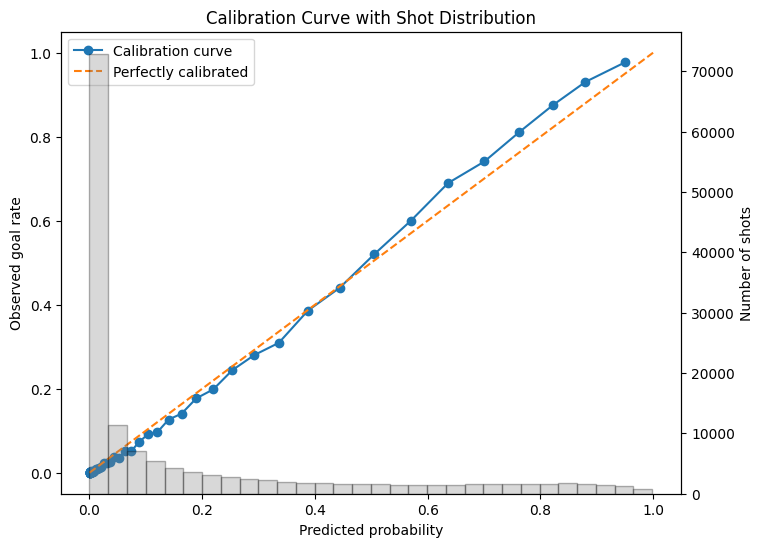

In [113]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(df_xg['is_goal'], df_xg['xG'], n_bins=50, strategy='quantile')

fig, ax1 = plt.subplots(figsize=(8,6))

# Calibration curve
ax1.plot(prob_pred, prob_true, marker='o', label='Calibration curve')
ax1.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
ax1.set_xlabel("Predicted probability")
ax1.set_ylabel("Observed goal rate")
ax1.set_title("Calibration Curve with Shot Distribution")
ax1.legend(loc='upper left')

# Secondary axis for histogram
ax2 = ax1.twinx()
ax2.hist(df_xg['xG'], bins=30, alpha=0.3, color='gray', edgecolor='black')
ax2.set_ylabel("Number of shots")

plt.show()


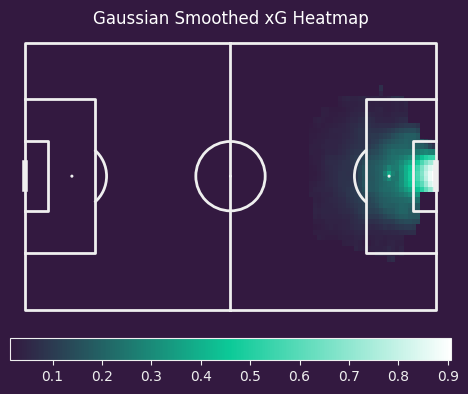

In [114]:
from mplsoccer import Pitch
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
df_filtered = df_xg[(df_xg['x'] > 50) & (df_xg['y'] > 0)]  # change thresholds as needed

# Custom colormap: dark purple → teal → white
colors = ['#331940', '#0cca98', 'white']
custom_cmap = LinearSegmentedColormap.from_list('xg_cmap', colors)

# Setup pitch
pitch = Pitch(pitch_type='opta', line_zorder=2,
              pitch_color='#331940', line_color='#efefef')  # dark purple pitch
fig, ax = pitch.draw(figsize=(6.6, 4.125))
fig.set_facecolor('#331940')  # figure background

# Compute mean xG per spatial bin
bin_statistic = pitch.bin_statistic(df_filtered['x'], df_filtered['y'], values=df_filtered['xG'],
                                    statistic='mean', bins=(100, 50))

# Apply Gaussian smoothing to the binned xG values
sigma = 0.75
smoothed_xG = gaussian_filter(bin_statistic['statistic'], sigma=sigma)
bin_statistic['statistic'] = smoothed_xG

# Plot heatmap with custom colormap, no bin borders
pcm = pitch.heatmap(bin_statistic, ax=ax, cmap=custom_cmap, edgecolors=None)

# Add colorbar at the bottom
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cbar.outline.set_edgecolor('#efefef')
cbar.ax.xaxis.set_tick_params(color='#efefef')
plt.setp(plt.getp(cbar.ax.axes, 'xticklabels'), color='#efefef')

plt.title('Gaussian Smoothed xG Heatmap', color='white')
plt.tight_layout()
plt.show()


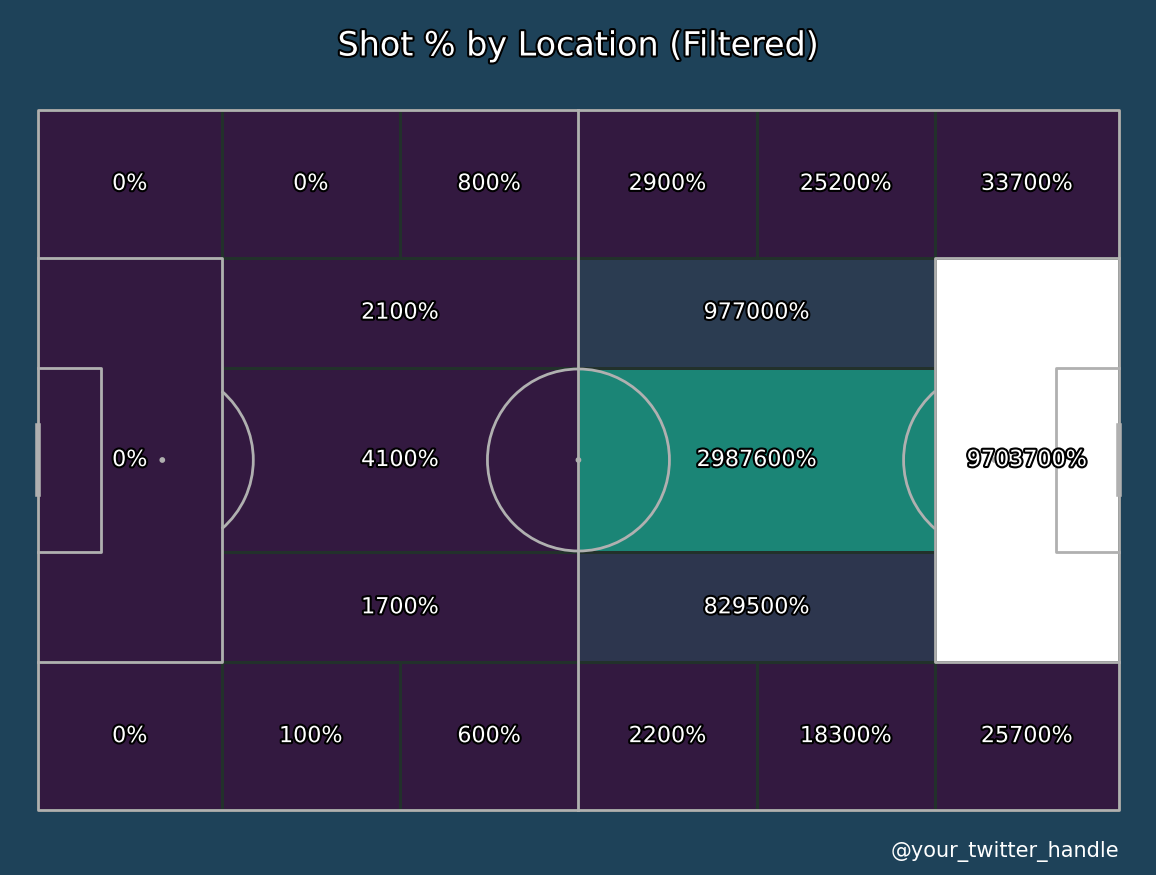

In [115]:
from mplsoccer import Pitch, cm
import matplotlib.pyplot as plt
from matplotlib import patheffects

# Define your min x or y filter (example: only shots closer to goal)
df_filtered = df_xg[(df_xg['x'] > 0) & (df_xg['y'] > 0)]  # change thresholds as needed

# Path effects for better contrast
path_eff = [patheffects.withStroke(linewidth=3, foreground='black')]

# Create a horizontal Opta pitch
pitch = Pitch(pitch_type='opta',
              line_zorder=2, pitch_color='#1e4259')
fig, axs = pitch.grid(endnote_height=0.03, endnote_space=0,
                      title_height=0.08, title_space=0,
                      axis=False, grid_height=0.84)
fig.set_facecolor('#1e4259')

# Bin the data: count of shots per zone
bin_statistic = pitch.bin_statistic_positional(
    df_filtered['x'], df_filtered['y'],
    values=None,
    statistic='count',
    positional='full',
    normalize=False  # ✅ this enables % of total
)

# Draw heatmap
pitch.heatmap_positional(bin_statistic, ax=axs['pitch'],
                         cmap=custom_cmap, edgecolors='#22312b')

# Add percentage labels
pitch.label_heatmap(bin_statistic, color='white', fontsize=16,
                    ax=axs['pitch'], ha='center', va='center',
                    str_format='{:.0%}', path_effects=path_eff)

# Add title and endnote
axs['title'].text(0.5, 0.5, "Shot % by Location (Filtered)", color='white',
                  va='center', ha='center', path_effects=path_eff, fontsize=24)

axs['endnote'].text(1, 0.5, '@your_twitter_handle', va='center', ha='right', fontsize=15,
                    color='white')

plt.show()


## Final Validation

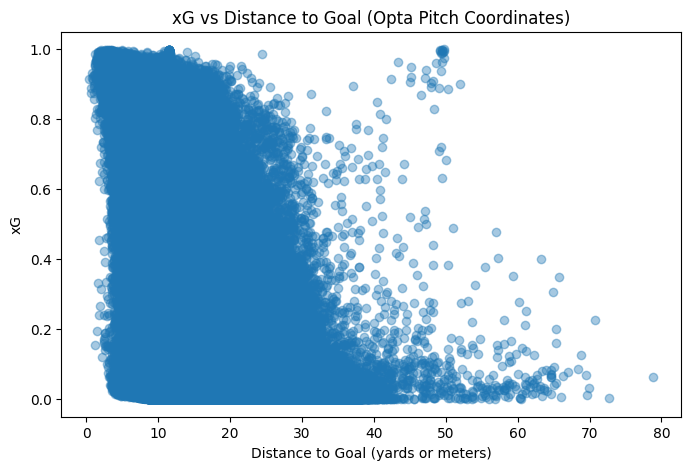

In [116]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate Euclidean distance from each shot to the center of the goal at (100, 50)
df_xg['distance'] = np.sqrt((100 - df_xg['x'])**2 + (50 - df_xg['y'])**2)

# Scatter plot xG vs Distance
plt.figure(figsize=(8,5))
plt.scatter(df_xg['distance'], df_xg['xG'], alpha=0.4)
plt.xlabel("Distance to Goal (yards or meters)")
plt.ylabel("xG")
plt.title("xG vs Distance to Goal (Opta Pitch Coordinates)")
plt.show()


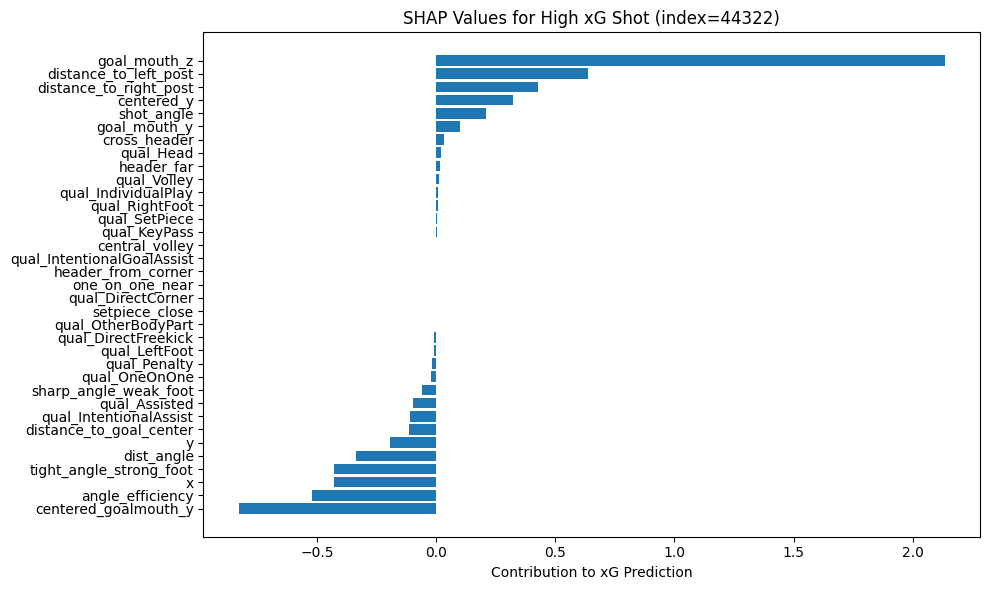


Top SHAP contributors to high xG:

                   feature  shap_value
23            goal_mouth_z    2.135053
20   distance_to_left_post    0.636403
21  distance_to_right_post    0.425853
18              centered_y    0.321868
17              shot_angle    0.209241
22            goal_mouth_y    0.097619
32            cross_header    0.031779
9                qual_Head    0.019740
28              header_far    0.014055
11             qual_Volley    0.012013

Feature values for this shot:

                                 44322
x                            27.600000
y                            18.800000
qual_IntentionalAssist        0.000000
qual_IntentionalGoalAssist    0.000000
qual_Assisted                 1.000000
qual_KeyPass                  0.000000
qual_IndividualPlay           1.000000
qual_RightFoot                0.000000
qual_LeftFoot                 1.000000
qual_Head                     0.000000
qual_OtherBodyPart            0.000000
qual_Volley                   0.000

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
from catboost import Pool

# ====== STEP 1: Identify suspicious high-xG shots far from goal ======
high_xg_far_shots = df_xg[(df_xg['x'] < 30)]
example_shot = high_xg_far_shots.iloc[0]
shot_index = example_shot.name

# ====== STEP 2: Prepare feature columns ======
# If you don't have feature_columns saved, try to get from model:
try:
    feature_columns = model.feature_names_
except AttributeError:
    # fallback: exclude known non-feature cols from df_xg
    non_features = ['xG', 'x', 'y', 'goal']  # adjust this list to your df
    feature_columns = [col for col in df_xg.columns if col not in non_features]

# ====== STEP 3: Prepare Pool with just the single shot ======
single_row = df_xg.loc[[shot_index], feature_columns]
single_pool = Pool(single_row, feature_names=feature_columns)

# ====== STEP 4: Get SHAP values for single shot ======
shap_values = model.get_feature_importance(single_pool, type="ShapValues")
# Remove last column (model output) for clarity
shap_contribs = shap_values[:, :-1].flatten()

# ====== STEP 5: Create a DataFrame for SHAP contributions ======
shap_df = pd.DataFrame({
    'feature': feature_columns,
    'shap_value': shap_contribs,
})

shap_df_sorted = shap_df.sort_values(by='shap_value', ascending=False)

# ====== STEP 6: Plot the SHAP values ======
plt.figure(figsize=(10, 6))
plt.barh(shap_df_sorted['feature'], shap_df_sorted['shap_value'])
plt.gca().invert_yaxis()
plt.title(f'SHAP Values for High xG Shot (index={shot_index})')
plt.xlabel('Contribution to xG Prediction')
plt.tight_layout()
plt.show()

# ====== Optional: Print top contributors ======
print("\nTop SHAP contributors to high xG:\n")
print(shap_df_sorted.head(10))

# ====== Optional: Print feature values for this shot ======
print("\nFeature values for this shot:\n")
print(single_row.T)


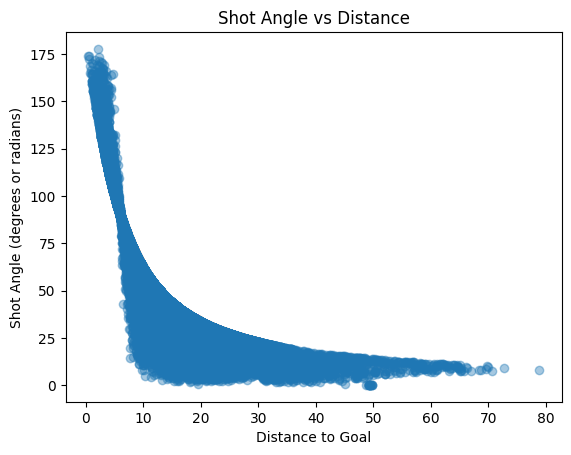

In [118]:
import matplotlib.pyplot as plt

plt.scatter(df_xg['distance'], df_xg['shot_angle'], alpha=0.4)
plt.xlabel("Distance to Goal")
plt.ylabel("Shot Angle (degrees or radians)")
plt.title("Shot Angle vs Distance")
plt.show()


In [119]:
df_xg.columns

Index(['x', 'y', 'qual_IntentionalAssist', 'qual_IntentionalGoalAssist',
       'qual_Assisted', 'qual_KeyPass', 'qual_IndividualPlay',
       'qual_RightFoot', 'qual_LeftFoot', 'qual_Head', 'qual_OtherBodyPart',
       'qual_Volley', 'qual_SetPiece', 'qual_DirectFreekick', 'qual_OneOnOne',
       'qual_Penalty', 'qual_DirectCorner', 'shot_angle', 'centered_y',
       'distance_to_goal_center', 'distance_to_left_post',
       'distance_to_right_post', 'goal_mouth_y', 'goal_mouth_z',
       'centered_goalmouth_y', 'dist_angle', 'one_on_one_near',
       'tight_angle_strong_foot', 'header_far', 'central_volley',
       'header_from_corner', 'sharp_angle_weak_foot', 'cross_header',
       'setpiece_close', 'angle_efficiency', 'is_goal', 'xG', 'distance'],
      dtype='object')

In [120]:
goal_shots = df_xg[df_xg['is_goal'] == 1]  # assuming 'goal' column: 1 if goal, else 0

print("Goal shots x coordinate:")
print(f"  min: {goal_shots['x'].min()}")
print(f"  max: {goal_shots['x'].max()}")

print("Goal shots y coordinate:")
print(f"  min: {goal_shots['y'].min()}")
print(f"  max: {goal_shots['y'].max()}")


Goal shots x coordinate:
  min: 52.8
  max: 99.9
Goal shots y coordinate:
  min: 0.3
  max: 99.8
